# 🔁 03-深度学习 · 模型笔记 4：RNN 与 LSTM（门控机制手写）

> RNN 是序列建模的基石，LSTM 用**门控**修好梯度消失。本笔记手推 BPTT、手写 RNN 训练、手写 LSTM 前向。
> 本 notebook 要求：**RNN/LSTM 全部手写 numpy，不调 torch.nn**；含每轮 loss 与预测样例中间输出。

**运行环境**：Python 3.8+，仅依赖 numpy。

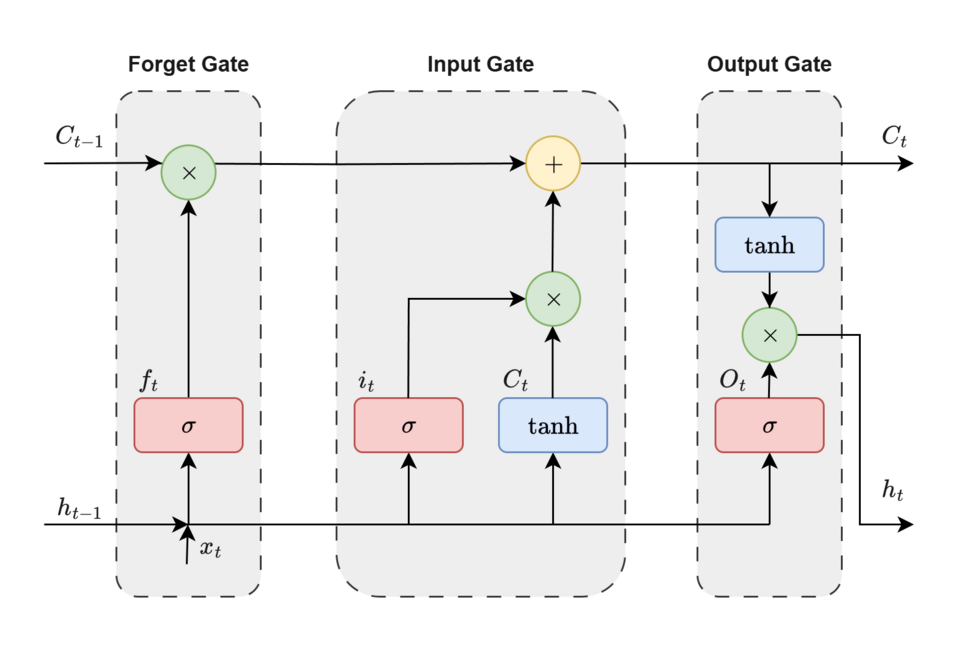

> 📷 LSTM 单元结构：遗忘门/输入门/输出门 + 细胞状态 C（“传送带”）
> *图源：Wikimedia Commons（开放授权）*


> 🚛 **传送带类比**：把细胞状态 $c_t$ 想成贯穿工厂的传送带。**遗忘门** $f$ 决定「旧货下不下车」——丢弃多少旧记忆；**输入门** $i$ 决定「新货装不装」——写入多少新信息（候选 $\tilde c_t$ 是待装的新货）；**输出门** $o$ 决定「当前展示多少」——放多少记忆到 $h_t$ 给下游使用。三个门都是 sigmoid（0~1）：开大 = 放行，开小 = 拦截。

## §1 RNN 前向：时间步展开

每个时间步共享同一组权重 $W_{xh}, W_{hh}, b_h$：

$$h_t = \tanh\big( W_{xh} x_t + W_{hh} h_{t-1} + b_h \big)$$

$$\hat{y}_t = W_{hy} h_t + b_y$$

- $x_t \in \mathbb{R}^{d}$：第 $t$ 个输入；$h_t \in \mathbb{R}^{H}$：隐藏状态（RNN 的「记忆」）
- 序列 $\{x_1, x_2, \dots, x_T\}$ 依次处理，$h_T$ 承载全序列信息

**关键性质**：权重跨时间步**共享**——参数量与序列长度无关，但反向要沿时间展开（BPTT）。

## §2 BPTT 推导与梯度消失根源

**反向传播通过时间（BPTT）**：总损失 = 各时间步损失之和，误差沿 $t \to t-1$ 回传。

**链式展开**（关键项）：

$$\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=2}^{T} \frac{\partial h_t}{\partial h_{t-1}} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=2}^{T} \operatorname{diag}\big(1 - h_t^2\big) W_{hh}$$

**梯度消失/爆炸的数学根源**：连乘项中 $\|W_{hh}\|$ 的 $T$ 次幂：

$$\Big( W_{hh}^{\top} \Big)^{T-1} \quad \Rightarrow \quad \|W_{hh}\| < 1 \ \text{梯度消失},\quad \|W_{hh}\| > 1 \ \text{梯度爆炸}$$

**tanh 导数 $1 - h_t^2 \le 1$ 加剧消失**（饱和时接近 0）。

缓解：梯度裁剪（爆炸）、更好的初始化（爆炸）、**LSTM 门控**（消失）。

In [ ]:
import numpy as np

class RNN:
    """手写 RNN：sin 序列预测（BPTT 全展开，numpy）"""
    def __init__(self, d, H, seed=0):
        r = np.random.default_rng(seed)
        scale = 0.5 / np.sqrt(H)          # 抑制梯度爆炸的初始化
        self.Wxh = r.normal(0, 0.1, (H, d))
        self.Whh = r.normal(0, scale, (H, H))
        self.bh = np.zeros(H)
        self.Wyh = r.normal(0, 0.1, (1, H))
        self.by = np.zeros(1)
        self.loss_hist = []

    def forward(self, seq):
        # seq: [T, d]；返回每步预测 [T,1] 并缓存中间量
        T = len(seq)
        self.seq = seq
        self.hs = np.zeros((T + 1, self.Whh.shape[0]))   # h_0 = 0
        self.zs = np.zeros((T, self.Whh.shape[0]))
        preds = np.zeros((T, 1))
        for t in range(T):
            self.zs[t] = self.Wxh @ seq[t] + self.Whh @ self.hs[t] + self.bh
            self.hs[t + 1] = np.tanh(self.zs[t])
            preds[t] = self.Wyh @ self.hs[t + 1] + self.by
        return preds

    def backward(self, targets, lr):
        # BPTT：沿时间步从后往前累加梯度
        T = len(targets)
        H = self.Whh.shape[0]
        gWxh = np.zeros_like(self.Wxh); gWhh = np.zeros_like(self.Whh)
        gbh = np.zeros(H); gWyh = np.zeros_like(self.Wyh); gby = np.zeros(1)
        dnext = np.zeros(H)               # dh_{t} 从后一时刻累积
        for t in range(T - 1, -1, -1):
            # 输出误差梯度：loss = mean((pred - y)^2) → d loss/d pred = 2*(pred - y)/T
            yerr = (2.0 / T) * ((self.Wyh @ self.hs[t + 1] + self.by) - targets[t])
            dWyh = np.outer(yerr, self.hs[t + 1])
            dby = yerr
            gWyh += dWyh; gby += dby
            dh = self.Wyh.T @ yerr + dnext
            dz = dh * (1 - self.hs[t + 1] ** 2)          # tanh'
            gWxh += np.outer(dz, self.seq[t])
            gWhh += np.outer(dz, self.hs[t])
            gbh += dz
            dnext = self.Whh.T @ dz                        # 往更早时刻传
        # 梯度裁剪（防爆炸演示）
        total = np.sqrt(gWxh.var() + gWhh.var() + gWyh.var() + 1e-12)
        clip = 5.0
        if total > clip:
            gWxh *= clip / total; gWhh *= clip / total; gWyh *= clip / total
            gbh *= clip / total; gby *= clip / total
        self.Wxh -= lr * gWxh; self.Whh -= lr * gWhh; self.bh -= lr * gbh
        self.Wyh -= lr * gWyh; self.by -= lr * gby
        return total

    def train(self, seq, targets, epochs=300, lr=0.01, verbose=False):
        for e in range(epochs):
            preds = self.forward(seq)
            loss = np.mean((preds - targets) ** 2)
            self.loss_hist.append(loss)
            gnorm = self.backward(targets, lr)
            if verbose and (e % 60 == 0 or e == epochs - 1):
                print(f'epoch {e:3d}: loss={loss:.6f}  梯度范数={gnorm:.4f}  首尾预测={preds[0,0]:+.3f}/{preds[-1,0]:+.3f}')

# sin 序列自回归：用前 40 步预测自身（一步预测）
T = 60
t_axis = np.linspace(0, 8 * np.pi, T)
seq = np.sin(t_axis).reshape(-1, 1)             # [T, 1]
targets = np.roll(seq, -1, axis=0)[:T - 1]      # 预测下一点
seq_in = seq[:T - 1]

rnn = RNN(d=1, H=32, seed=0)
rnn.train(seq_in, targets, epochs=300, lr=0.02, verbose=True)
preds = rnn.forward(seq_in)
print('\n一步预测对比（前 5 点 真实→预测）:')
for i in range(5):
    print(f'  t={i}: 真实 {targets[i,0]:+.4f}  预测 {preds[i,0]:+.4f}')
print('最终 MSE =', round(rnn.loss_hist[-1], 5), '（RNN 学到了 sin 的下一点模式）')

In [ ]:
# ---- 梯度检查：中心差分数值梯度 vs 手写 BPTT（小网络，确保不触发梯度裁剪）----
rng_chk = np.random.default_rng(42)
seq_chk = rng_chk.normal(0, 1, (5, 2))
tar_chk = np.sin(np.arange(5)).reshape(-1, 1)

rnn_chk = RNN(d=2, H=4, seed=123)
Wxh0, Whh0, bh0 = rnn_chk.Wxh.copy(), rnn_chk.Whh.copy(), rnn_chk.bh.copy()
Wyh0, by0 = rnn_chk.Wyh.copy(), rnn_chk.by.copy()

lr_chk = 0.1
rnn_chk.forward(seq_chk)                                   # 缓存前向中间量
gnorm = rnn_chk.backward(tar_chk, lr_chk)                  # 手写 BPTT
assert gnorm < 5.0, f'梯度范数 {gnorm:.4f} 触发了裁剪，检查不可比'

# 从参数更新反解手写梯度：(W_old - W_new)/lr
gWxh = (Wxh0 - rnn_chk.Wxh) / lr_chk
gWhh = (Whh0 - rnn_chk.Whh) / lr_chk
gbh = (bh0 - rnn_chk.bh) / lr_chk
gWyh = (Wyh0 - rnn_chk.Wyh) / lr_chk
gby = (by0 - rnn_chk.by) / lr_chk

# 恢复原始权重，做中心差分数值梯度
rnn_chk.Wxh, rnn_chk.Whh, rnn_chk.bh = Wxh0.copy(), Whh0.copy(), bh0.copy()
rnn_chk.Wyh, rnn_chk.by = Wyh0.copy(), by0.copy()

def loss_of(rnn, seq, y):
    pred = rnn.forward(seq)
    return np.mean((pred - y) ** 2)

def numeric_grad(rnn, seq, y, eps=1e-6):
    grads = []
    for P in (rnn.Wxh, rnn.Whh, rnn.bh, rnn.Wyh, rnn.by):
        g = np.zeros_like(P)
        for idx in np.ndindex(P.shape):
            old = P[idx]
            P[idx] = old + eps
            lp = loss_of(rnn, seq, y)
            P[idx] = old - eps
            lm = loss_of(rnn, seq, y)
            P[idx] = old
            g[idx] = (lp - lm) / (2 * eps)
        grads.append(g)
    return grads

ng = numeric_grad(rnn_chk, seq_chk, tar_chk)
for name, hg, ng_p in zip(['Wxh', 'Whh', 'bh', 'Wyh', 'by'],
                          [gWxh, gWhh, gbh, gWyh, gby], ng):
    ok = np.allclose(hg, ng_p, rtol=1e-4, atol=1e-6)
    err = float(np.max(np.abs(hg - ng_p)))
    print(f'  {name:4s} allclose={ok}  最大偏差={err:.2e}')
    assert ok, f'{name} 手写梯度与数值梯度不一致'

print('✓ 梯度检查通过：手写 BPTT 与 loss = mean((pred-y)^2) 的数值梯度一致（yerr 含 2/T 因子）')

## §3 LSTM：三门 + 细胞状态（手写前向）

LSTM 引入**细胞状态 $c_t$**（记忆主线）与三个门控：

**门（sigmoid 输出 0~1，控制信息流）**：

$$f_t = \sigma\big( W_f [h_{t-1}, x_t] + b_f \big) \quad \text{遗忘门：丢弃多少旧记忆}$$

$$i_t = \sigma\big( W_i [h_{t-1}, x_t] + b_i \big) \quad \text{输入门：写入多少新信息}$$

$$o_t = \sigma\big( W_o [h_{t-1}, x_t] + b_o \big) \quad \text{输出门：放出多少记忆}$$

**候选记忆**（tanh 挤压）：

$$\tilde{c}_t = \tanh\big( W_c [h_{t-1}, x_t] + b_c \big)$$

**细胞状态更新**（线性累积——梯度高速路）：

$$c_t = f_t \circ c_{t-1} + i_t \circ \tilde{c}_t$$

**隐藏状态**：

$$h_t = o_t \circ \tanh(c_t)$$

**为什么修复梯度消失**：$c_t$ 的更新对 $c_{t-1}$ 的导数是**逐元素的 $f_t$**（线性、无连乘 $W_{hh}^T$ 指数放大）——旧信息可以几乎无损穿过长序列（$f \approx 1$）。

### §3.1 LSTM 反向推导：误差沿细胞状态直线回传

输出误差先经 $h_t = o_t \circ \tanh(c_t)$ 汇入细胞状态（$\delta h_t$ 含输出层回传与后续时刻）：

$$\delta c_t = \big(\delta h_t \circ o_t\big) \circ \big(1 - \tanh^2(c_t)\big) \;+\; \delta c_{t+1} \circ f_{t+1}$$

**遗忘门把误差传回旧细胞**——细胞状态的递归是误差跨时间传播的「高速公路」：

$$\delta c_{t-1} = \delta c_t \circ f_t \;+\; \big(\delta h_{t-1} \circ o_{t-1}\big) \circ \big(1 - \tanh^2(c_{t-1})\big)$$

> 关键机制：$\partial c_t / \partial c_{t-1} = f_t$（逐元素、线性）。误差沿细胞状态**乘 $f_t$ 而非 $\tanh'$**，没有 $W_{hh}^\top$ 矩阵连乘的指数放大——这就是 LSTM 缓解梯度消失的原因（$f \approx 1$ 时误差几乎无损直传）。

四组门各自的误差（对应各自的输入，再乘激活函数导数）：

$$\delta z^f_t = \big(\delta c_t \circ c_{t-1}\big) \circ \sigma'(z^f_t), \qquad \delta z^i_t = \big(\delta c_t \circ \tilde c_t\big) \circ \sigma'(z^i_t)$$

$$\delta z^o_t = \big(\delta h_t \circ \tanh(c_t)\big) \circ \sigma'(z^o_t), \qquad \delta z^{\tilde c}_t = \big(\delta c_t \circ i_t\big) \circ \big(1 - \tilde c_t^2\big)$$

把四段拼回 $z_t = W [h_{t-1}; x_t] + b$ 的梯度（$W$ 即「拼接权重」，含 $W_{hh}$ 与 $W_{xh}$ 两部分）：

$$\delta z_t = \big[\delta z^f_t;\, \delta z^i_t;\, \delta z^o_t;\, \delta z^{\tilde c}_t\big], \qquad \frac{\partial L}{\partial W} = \sum_t \delta z_t\, [h_{t-1}; x_t]^\top, \qquad \frac{\partial L}{\partial b} = \sum_t \delta z_t$$

**一句话**：误差沿 $c_t$ 直线回传只被 $f_t$ 缩放（线性、无 $\tanh'$ 连乘），四门梯度各自把误差按「门前的输入」分配到对应权重——$f$ 门接近 1 时，长距离依赖的梯度不消失。

In [ ]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    out[~pos] = np.exp(z[~pos]) / (1.0 + np.exp(z[~pos]))
    return out

class LSTMCell:
    """手写 LSTM 前向单元（单层）"""
    def __init__(self, d, H, seed=0):
        r = np.random.default_rng(seed)
        self.H = H
        # 拼接输入 [h_{t-1}; x_t] → 4 组门/候选
        self.W = r.normal(0, 0.1, (4 * H, H + d))
        self.b = np.zeros(4 * H)

    def forward(self, x_seq):
        """x_seq: [T, d] → hs: [T+1, H], cs: [T+1, H]（含 h0=c0=0）"""
        T, H = len(x_seq), self.H
        hs = np.zeros((T + 1, H)); cs = np.zeros((T + 1, H))
        gate_stats = {'f': [], 'i': [], 'o': []}
        for t in range(T):
            xt = x_seq[t]
            z = self.W @ np.concatenate([hs[t], xt]) + self.b   # [4H]
            f = sigmoid(z[:H]); i = sigmoid(z[H:2 * H])
            o = sigmoid(z[2 * H:3 * H]); g = np.tanh(z[3 * H:])
            cs[t + 1] = f * cs[t] + i * g                       # 细胞状态
            hs[t + 1] = o * np.tanh(cs[t + 1])                  # 隐藏状态
            gate_stats['f'].append(f); gate_stats['i'].append(i); gate_stats['o'].append(o)
        return hs, cs, gate_stats

T, d, H = 20, 3, 8
rng = np.random.default_rng(1)
x_seq = rng.normal(0, 1, (T, d))
cell = LSTMCell(d, H, seed=0)
hs, cs, gs = cell.forward(x_seq)
print('隐藏状态形状 [T+1, H]:', hs.shape, ' 细胞状态形状:', cs.shape)
print('遗忘门均值（应接近 0.5~0.9，倾向保留记忆）:', round(np.mean(gs['f']), 3))
print('输出门均值:', round(np.mean(gs['o']), 3))
print('c_t 与 h_t 关系检查: h = o·tanh(c) →',
      round(np.allclose(hs[-1], gs['o'][-1] * np.tanh(cs[-1])), 2), '✓')

# 记忆保持演示：注入恒定输入，观察 c_t 是否平缓衰减（f 门接近 1 时近乎恒定）
x_const = np.tile(np.array([1.0, 0.0, 0.0]), (40, 1))
hs2, cs2, gs2 = cell.forward(x_const)
print('恒输入 40 步后 |c| 保持（未消失）:', round(np.abs(cs2[-1]).mean(), 4),
      '  vs 最初:', round(np.abs(cs2[1]).mean(), 4))
print('→ LSTM 细胞状态沿时间近线性累积，长程记忆不衰减（RNN 则指数消失）')

In [ ]:
# ---- torch.nn.LSTM 对照：手写 LSTM 前向 vs PyTorch 官方实现 ----
import torch

torch.manual_seed(0)
np.random.seed(0)
seq_len, batch, d, H = 4, 2, 8, 8
x = torch.randn(seq_len, batch, d)          # [T, B, D]，batch_first=False

# PyTorch 门顺序：i, f, g, o（每门 H 行）；手写实现顺序：f, i, o, g
lstm = torch.nn.LSTM(d, H, batch_first=False)
cell_ref = LSTMCell(d, H, seed=0)           # 复用手写单元，仅替换权重
with torch.no_grad():
    W_ih = lstm.weight_ih_l0.numpy()                        # [4H, d]
    W_hh = lstm.weight_hh_l0.numpy()                        # [4H, H]
    b_ih = lstm.bias_ih_l0.numpy()
    b_hh = lstm.bias_hh_l0.numpy()

H4 = 4 * H
i_idx = np.arange(0, H); f_idx = np.arange(H, 2 * H)
g_idx = np.arange(2 * H, 3 * H); o_idx = np.arange(3 * H, 4 * H)
perm = np.concatenate([f_idx, i_idx, o_idx, g_idx])         # torch 顺序 → 手写顺序

# 同一拼接权重：W = [W_hh | W_ih]（4H × (H+d)），与手写 z = W @ [h_{t-1}; x_t] 对应
cell_ref.W = np.hstack([W_hh, W_ih])[perm]   # 列拼接 [W_hh | W_ih] -> [4H, H+d]
cell_ref.b = (b_ih + b_hh)[perm]

x_np = x.numpy()
with torch.no_grad():
    out, (h_n, c_n) = lstm(x)                               # out: [T, B, H]

max_err = 0.0
for b in range(batch):
    hs_my, cs_my, _ = cell_ref.forward(x_np[:, b, :])       # 每 batch 一条序列
    my_h = hs_my[1:]                                        # [T, H]
    ref_h = out[:, b, :].numpy()
    ok_h = np.allclose(my_h, ref_h, rtol=1e-4, atol=1e-5)
    ok_c = np.allclose(cs_my[-1], c_n[:, b].numpy(), rtol=1e-4, atol=1e-5)
    err_h = float(np.max(np.abs(my_h - ref_h)))
    max_err = max(max_err, err_h)
    print(f'  batch {b}: 隐藏状态 allclose={ok_h}  细胞状态 allclose={ok_c}  最大误差={err_h:.2e}')

print('最大隐藏状态误差 =', max_err)
assert max_err < 1e-4, 'torch 对照失败：手写 LSTM 与 nn.LSTM 不一致'
print('✓ torch 对照通过：手写 LSTM（同权重拼接 W=[W_hh|W_ih]）与 torch.nn.LSTM 前向一致')

## §4 LSTM vs RNN vs GRU（必背对比）

| 维度 | RNN | LSTM | GRU |
|------|-----|------|-----|
| 状态 | $h_t$（单线） | $h_t, c_t$（双线） | $h_t$（单线，两个门） |
| 门数 | 0 | 3（f/i/o）+候选 | 2（重置 r、更新 z） |
| 参数量 | 最小 | 最大 | 居中 |
| 长程记忆 | ✗（连乘消失） | ✓（$c_t$ 线性累加） | ✓（更新门插值） |
| 梯度 | 易消失/爆炸 | 稳定 | 稳定 |

**GRU 公式**（LSTM 简化版，无 $c_t$、无独立遗忘门）：

$$z_t = \sigma(W_z [h_{t-1}, x_t]), \quad r_t = \sigma(W_r [h_{t-1}, x_t])$$

$$\tilde{h}_t = \tanh\big( W [r_t \circ h_{t-1}, x_t] \big), \quad h_t = (1 - z_t) \circ h_{t-1} + z_t \circ \tilde{h}_t$$

**选择**：数据量小/任务简单 → GRU（省参数）；长文本/复杂依赖 → LSTM；当今大模型用 **Transformer**（自注意力，见用户自有 LLM 资料）。

## §5 常见 bug 与边界（面试踩坑区）

- **h0/c0 初始化**：必须从 0 开始（或可学习初值），忘了会让第一帧语义漂移
- **拼接维度顺序**：$[h_{t-1}; x_t]$ 的拼接顺序要与权重列布局一致（本文 H+d 布局 = h 在前）
- **tanh 导数忘乘**：BPTT 里 $dh$ 必须乘 $1 - h^2$，漏了梯度爆炸
- **梯度裁剪**：RNN 必做 `clip`（上面演示），否则爆炸把权重冲成 NaN
- **预测 vs 训练的步进方式**：训练用真实序列逐点喂；推理要**自回归**（上一步输出当输入）
- **门初始化**：LSTM 遗忘门偏置常初始化为 1（`b_f=1`）让早期默认不遗忘——PyTorch 默认 0 也常见
- **BPTT 展开长度**：长序列用截断 BPTT（每 k 步反向），全展开内存 O(T·H)

## §6 面试追问与扩展（加分项）

### 6.1 LSTM 为什么能修梯度消失（一句话）

细胞状态 $c_t = f_t \circ c_{t-1} + i_t \circ \tilde{c}_t$ 对旧状态的导数 = $f_t$（逐元素、线性、无矩阵连乘）——误差可以沿这条「高速路」无损回传。

### 6.2 梯度爆炸呢

爆炸仍可能（输出路径 $W_{hy}$ 等）→ 梯度裁剪（norm clip）是标准做法。

### 6.3 RNN 的三种输出模式

many-to-many（翻译/序列标注）、many-to-one（情感分类，取 $h_T$）、one-to-many（文本生成）。

### 6.4 工程现状

RNN/LSTM 在长序列上被 Transformer 取代（并行化 + 全局注意力）；但**时序建模轻任务、以及强先验场景**仍有用武之地（语音、Trajectory）。

## §7 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 问）

- [ ] 1. 写出 RNN 前向公式（含 $h_{t-1}$ 项）
- [ ] 2. 解释权重跨时间共享
- [ ] 3. 写出 LSTM 六组公式（f/i/o/c̃/c/h）
- [ ] 4. 手写 RNN 前向（numpy）
- [ ] 5. 手写 LSTM 前向（numpy）
- [ ] 6. 推导梯度消失根源（连乘项）
- [ ] 7. 解释 LSTM 细胞状态为何抗消失
- [ ] 8. 梯度裁剪的作用与实现
- [ ] 9. 手写 BPTT（sin 预测示例）
- [ ] 10. 说出 LSTM 三个门各自作用

### L2 进阶（10 问）

- [ ] 11. 手写 LSTM 反向（四组权重梯度）
- [ ] 12. GRU 公式与 LSTM 差异
- [ ] 13. 手写截断 BPTT
- [ ] 14. 遗忘门偏置初始化实验（b_f=1 vs 0）
- [ ] 15. RNN 三种输出模式手写（many-to-many 等）
- [ ] 16. 手写梯度爆炸观察实验（不裁剪 vs 裁剪）
- [ ] 17. 双向 RNN 概念与实现
- [ ] 18. 手写字符级文本生成（RNN 采样）
- [ ] 19. Embedding 层 + RNN 组合手写
- [ ] 20. 长序列内存分析（O(T·H)）

### L3 挑战（5 问）

- [ ] 21. 完整 LSTM BPTT 推导（四权重导数）
- [ ] 22. 手写 Peephole LSTM / ConvLSTM
- [ ] 23. Seq2Seq + Attention 手写（编码器-解码器）
- [ ] 24. 手写 Truncated BPTT + 状态携带
- [ ] 25. RNN 时间序列基准实验（ARIMA vs RNN）

### 自测要点

- 白板推导 BPTT 连乘项与消失根源
- 10 分钟内默写 LSTM 六公式
- 讲清「为什么 LSTM 加了一条路」

## 附录：参考与下节预告

- Hochreiter & Schmidhuber 1997：LSTM 原论文
- 花书《深度学习》第 10 章（序列建模）

### 下节预告：模型笔记 5 — 批量归一化 BN（手写前向/反向 + 训练推理差异）

> 💡 本笔记验收：`03-深度学习/README.md` 验收清单「LSTM 必含」打勾。